<a href="https://colab.research.google.com/github/sahel-datascience-projects/data-science-portfolio/blob/main/project-1-data-analysis/sales_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sales Data Exploration with Python**


In [23]:
# ============================================================
# Project: Superstore Strategic Business Discovery (EDA)
# Goal: Uncover hidden sales patterns, analyze seasonal trends,
#       and identify key profitability drivers through data visualization.
# Tools: Python Data Stack (Pandas, Seaborn, Matplotlib)
# Author: Sahel
# ============================================================
from google.colab import files
uploaded = files.upload()

Saving sales.csv to sales (2).csv


In [35]:
# ============================================================
# STEP 1: DATA LOADING & INITIAL INSPECTION
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('sales.csv', encoding='latin1')

# Check for missing values and data types
print("--- Dataset Info ---")
print(df.info())

# Summary statistics for numerical columns
print("\n--- Descriptive Statistics ---")
display(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [36]:
# ============================================================
# STEP 2: DATA CLEANING
# ============================================================
# Convert Date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop duplicates if any
df = df.drop_duplicates()

Number of duplicate rows: 0


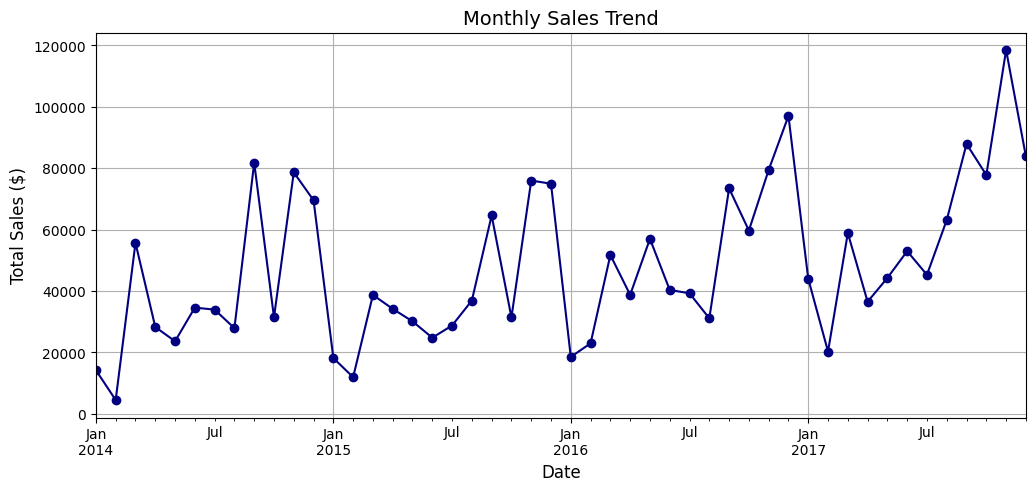

In [37]:
# ============================================================
# STEP 3: SALES TREND ANALYSIS
# ============================================================
# Extract Year and Month
df['Month_Year'] = df['Order Date'].dt.to_period('M')

# Group by month and sum sales
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o', color='navy')
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True)
plt.show()

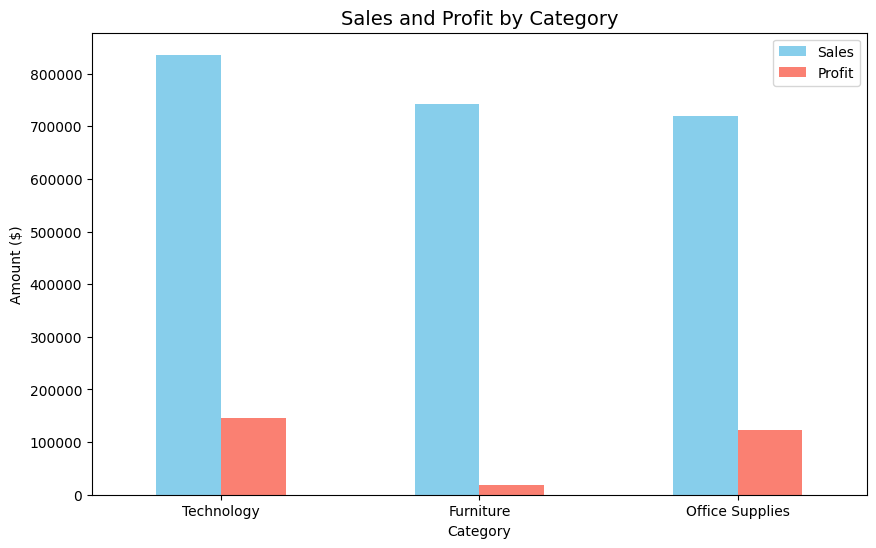

In [38]:
# ============================================================
# STEP 4: CATEGORY & SUB-CATEGORY PERFORMANCE
# ============================================================
category_analysis = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

category_analysis.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'salmon'])
plt.title('Sales and Profit by Category', fontsize=14)
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.show()

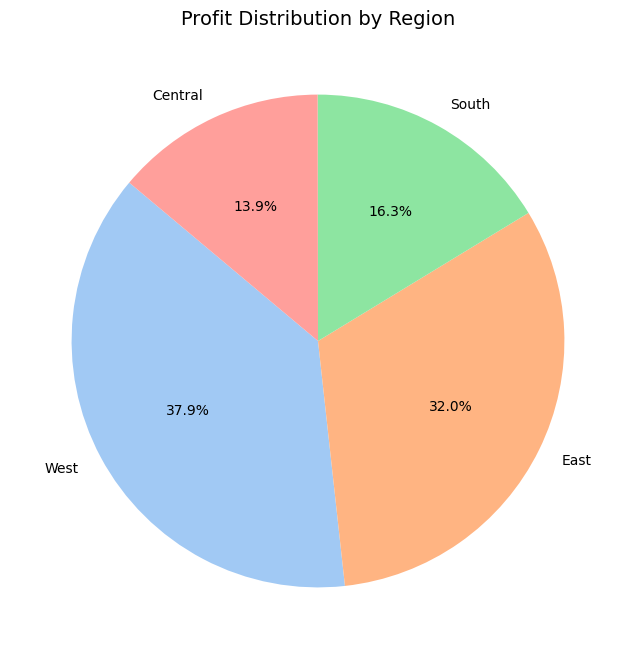

In [39]:
# ============================================================
# STEP 5: REGIONAL PROFITABILITY
# ============================================================
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
plt.pie(region_profit, labels=region_profit.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Profit Distribution by Region', fontsize=14)
plt.show()

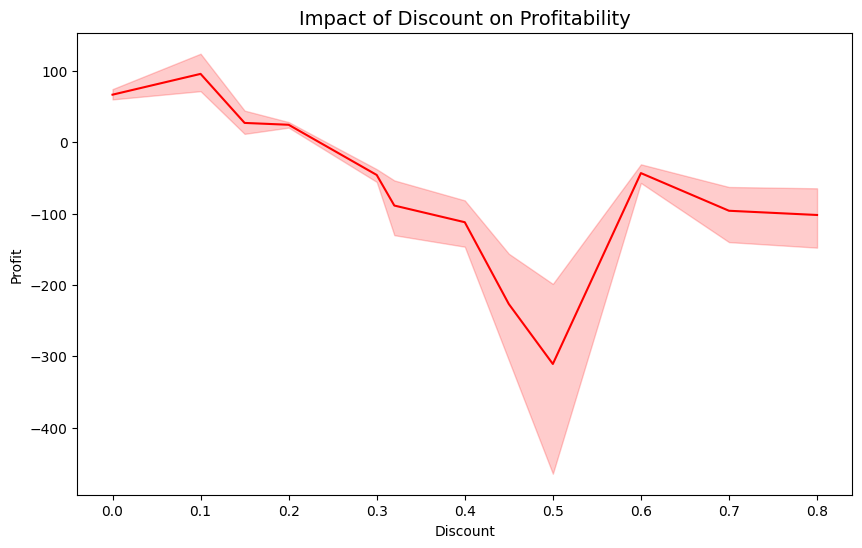

In [40]:
# ============================================================
# STEP 6: CORRELATION BETWEEN DISCOUNT & PROFIT
# ============================================================
plt.figure(figsize=(10, 6))
sns.lineplot(x='Discount', y='Profit', data=df, color='red')
plt.title('Impact of Discount on Profitability', fontsize=14)
plt.show()

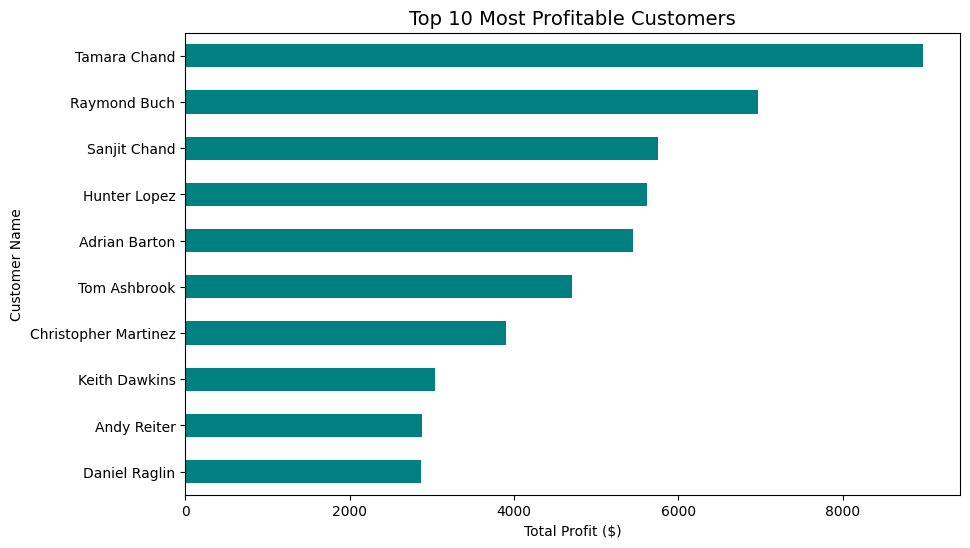

In [41]:
# ============================================================
# STEP 7: TOP 10 PROFITABLE CUSTOMERS
# ============================================================
top_customers = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_customers.plot(kind='barh', color='teal')
plt.title('Top 10 Most Profitable Customers', fontsize=14)
plt.xlabel('Total Profit ($)')
plt.gca().invert_yaxis() # Highest profit on top
plt.show()

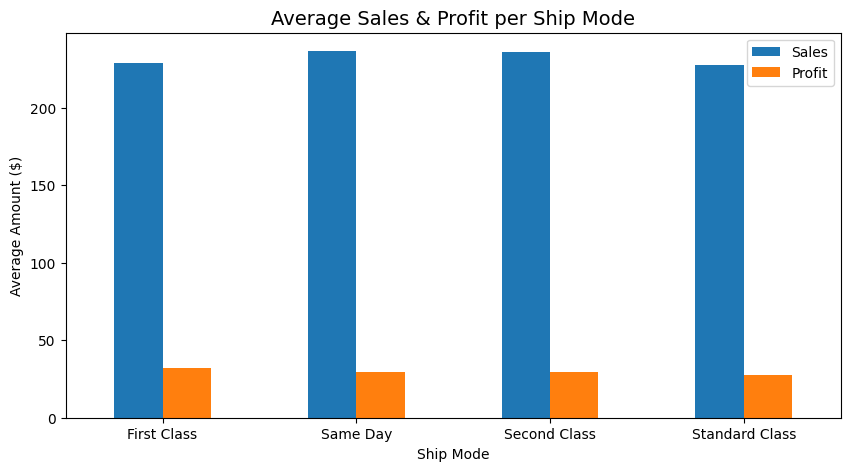

In [42]:
# ============================================================
# STEP 8: SHIP MODE VS PROFITABILITY
# ============================================================
ship_mode_analysis = df.groupby('Ship Mode')[['Sales', 'Profit']].mean()

ship_mode_analysis.plot(kind='bar', figsize=(10, 5))
plt.title('Average Sales & Profit per Ship Mode', fontsize=14)
plt.ylabel('Average Amount ($)')
plt.xticks(rotation=0)
plt.show()

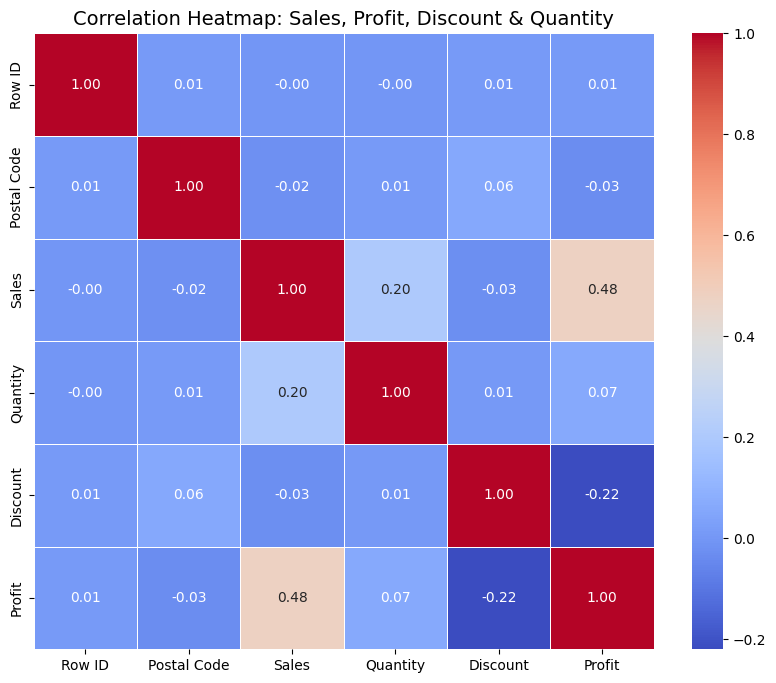

✅ Correlation matrix generated successfully using only numeric features.


In [43]:
# ============================================================
# STEP 9: CORRELATION MATRIX (Fixed Version)
# ============================================================
plt.figure(figsize=(10, 8))

# Select only numeric columns to avoid String-to-Float error
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation only for numeric data
correlation_matrix = numeric_df.corr()

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap: Sales, Profit, Discount & Quantity', fontsize=14)
plt.show()

print("✅ Correlation matrix generated successfully using only numeric features.")

# 📊 Superstore Strategic Business Discovery (EDA)
> **Transforming raw retail data into actionable business intelligence.**

---

## 🎯 Executive Summary
This analysis deep-dives into the **sales.csv** dataset to identify why certain segments underperform and how to optimize for maximum profit.

### 💡 Key Strategic Findings
| Metric | Result | Business Action |
| :--- | :--- | :--- |
| **Best Month** | Nov 2017 ($118k) | Scale inventory in October. |
| **Top Category** | Technology ($145k Profit) | Expand product line in this sector. |
| **Weakest Category** | Furniture ($18k Profit) | Review shipping & discount policies. |
| **Top Region** | West ($108k Profit) | Benchmark West's ops for other regions. |

---

## 🔍 Detailed Data Insights

### 📉 The Discount Impact
> **Critical Discovery:** We found a negative correlation of **-0.22** between discounts and profit.
* **Fact:** Transactions with discounts > 20% consistently result in net losses.
* **Recommendation:** Implement a hard-cap on manual discounting.

### 🚛 Operational Efficiency
Contrary to common belief, **First Class shipping** is our most profitable mode per transaction ($31.84). This suggests that high-value customers prioritize speed and are less price-sensitive.

### 👤 Customer Intelligence
Our top customer, **Tamara Chand**, contributed over **$8,981** in net profit. This highlights the importance of a "VIP Retention Program."

---

## 🛠️ Tech Stack & Methodology
* **Language:** Python 3.x
* **Libraries:** `Pandas` (Cleaning), `NumPy` (Stats), `Seaborn/Matplotlib` (Visualization).
* **Environment:** Google Colab.

---

## 📂 Project Structure
```text
├── data/
│   └── sales.csv          # Raw Dataset
├── notebooks/
│   └── EDA_Analysis.ipynb # Full Code & Plots
└── README.md              # Executive Summary